[DONE] P308166 p17  P2T=31.6ms(MOD)  HF=8.85  Coh=1.000  lag=-16.2s


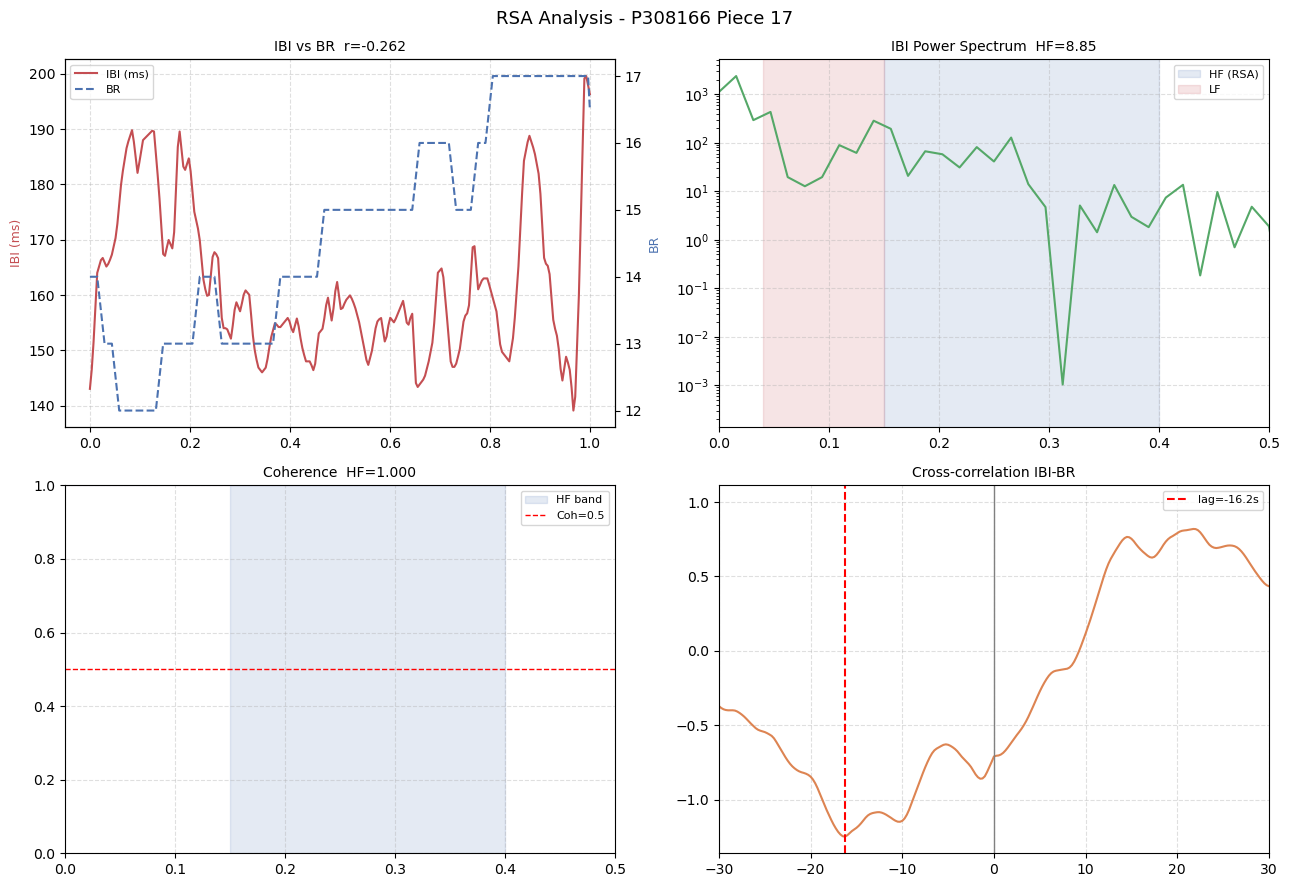

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\rsa_P308166_piece17.png
[DONE] P308166 p17  P2T=45.0ms(MOD)  HF=17.81  Coh=1.000  lag=36.8s


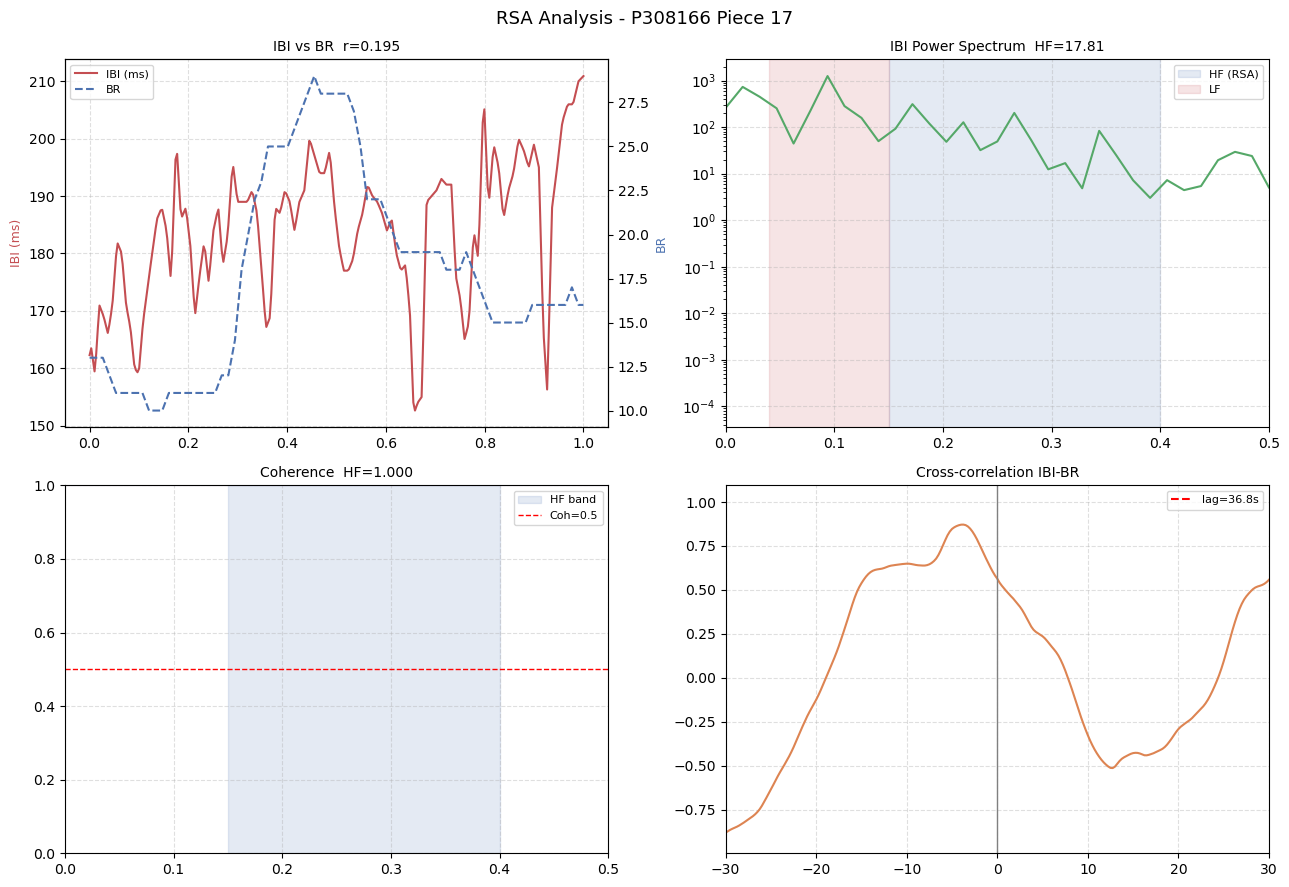

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\rsa_P308166_piece17.png
[DONE] P308166 p17  P2T=43.2ms(MOD)  HF=23.99  Coh=0.121  lag=38.0s


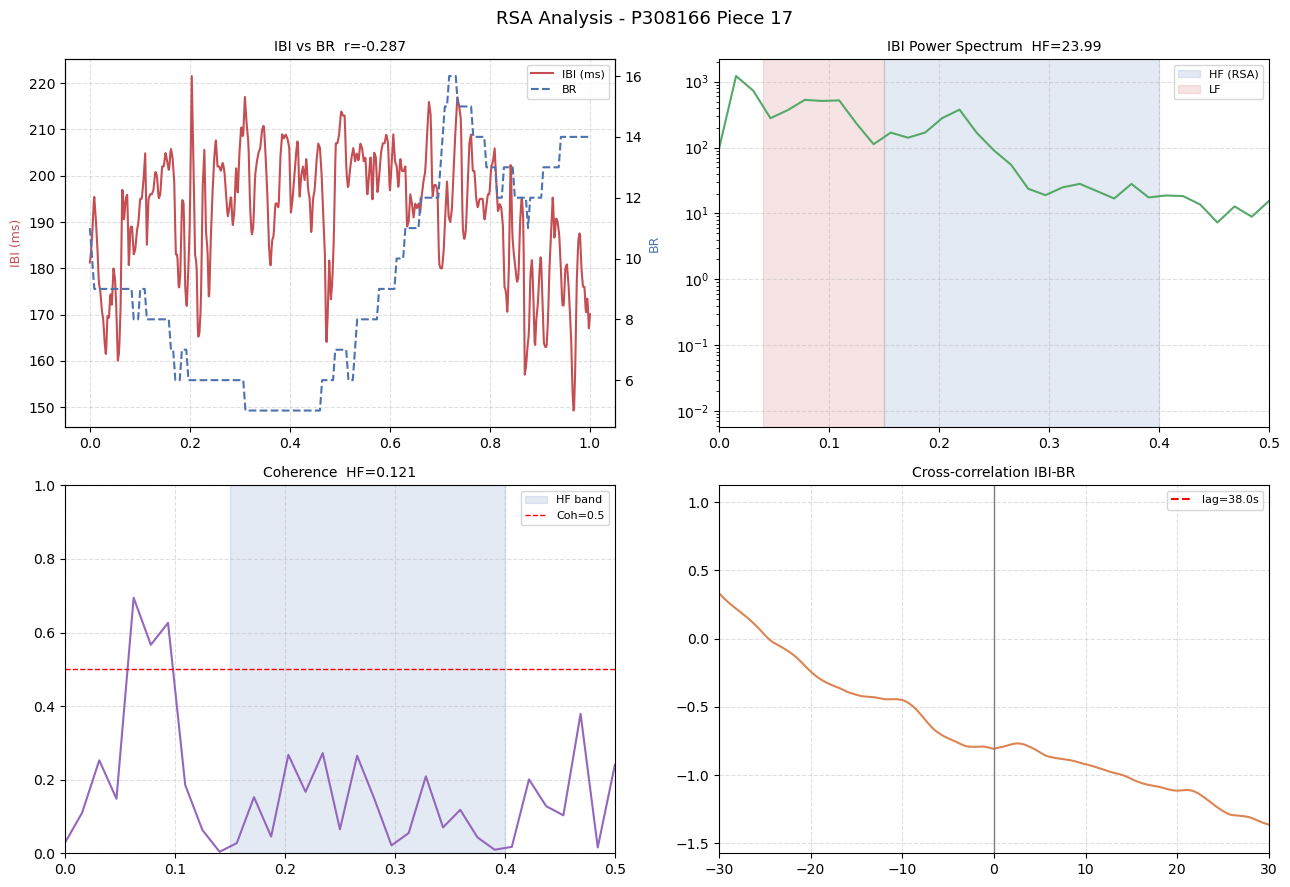

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\rsa_P308166_piece17.png
[DONE] P308168 p16  P2T=304.2ms(HIGH)  HF=1861.07  Coh=0.365  lag=72.2s
[DONE] P308168 p16  P2T=297.9ms(HIGH)  HF=1367.60  Coh=1.000  lag=-30.8s
[DONE] P308168 p16  P2T=271.4ms(HIGH)  HF=2787.84  Coh=1.000  lag=-3.5s
[DONE] P308169 p16  P2T=11.4ms(LOW)  HF=168.95  Coh=1.000  lag=-1.2s
[DONE] P308169 p16  P2T=176.5ms(HIGH)  HF=344.06  Coh=1.000  lag=47.5s
[DONE] P308169 p17  P2T=53.3ms(HIGH)  HF=25.45  Coh=0.525  lag=24.8s
[DONE] P308232 p17  P2T=15.5ms(LOW)  HF=1.29  Coh=1.000  lag=27.8s
[DONE] P308232 p17  P2T=14.5ms(LOW)  HF=1.39  Coh=1.000  lag=8.8s
[DONE] P308232 p17  P2T=9.6ms(LOW)  HF=3.87  Coh=0.549  lag=-11.5s
[DONE] P308233 p17  P2T=37.8ms(MOD)  HF=9.25  Coh=0.595  lag=-17.8s
[DONE] P308233 p16  P2T=41.6ms(MOD)  HF=2.18  Coh=1.000  lag=-12.8s
[DONE] P308233 p16  P2T=55.4ms(HIGH)  HF=33.05  Coh=0.099  lag=-5.5s
[DONE] P308234 p17  P2T=29.8ms(MOD)  HF=8.51  Coh=0.423  lag=0.0s
[DONE] P308234 p17  P

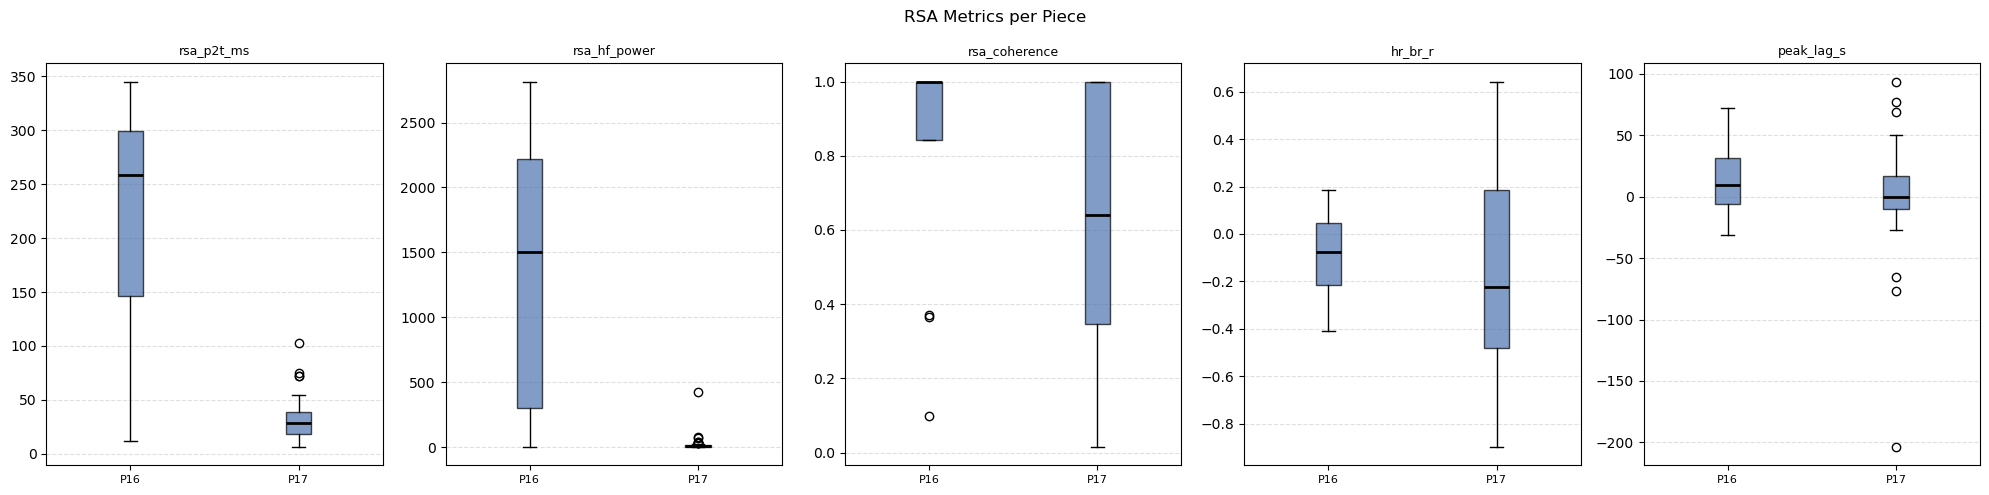

[SAVED] rsa_results.csv  rsa_group_summary.png


In [ ]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')


def load_wav(folder, fname, lo, hi):
    sys.path.insert(0, folder)
    import load_hx_data
    load_hx_data.set_device_model('hx')
    path = os.path.join(folder, fname)
    if not os.path.exists(path): return None, None
    df = pd.DataFrame(load_hx_data.load_wave(path), columns=['time','val'])
    t, v = df['time'].to_numpy(), df['val'].to_numpy()
    if v.mean() > 1000: v = v / 1000
    mask = (v >= lo) & (v <= hi)
    return t[mask], v[mask]


def load_rr(folder):
    path = os.path.join(folder, 'RR_interval.csv')
    if not os.path.exists(path): return None, None
    df = pd.read_csv(path)
    t, rr = df.iloc[:,0].to_numpy(), df.iloc[:,1].to_numpy()
    if rr.mean() > 10: rr = rr / 1000
    return t, rr


def compute_rsa(rr_t, rr_v, br_t, br_v, sr=4):
    t0, t1 = max(rr_t[0], br_t[0]), min(rr_t[-1], br_t[-1])
    if t1 - t0 < 10: return None
    tc  = np.arange(t0, t1, 1/sr)
    ibi = interp1d(rr_t, rr_v*1000, bounds_error=False, fill_value='extrapolate')(tc)
    br  = interp1d(br_t, br_v,      bounds_error=False, fill_value='extrapolate')(tc)

    # Method 1 - Peak-to-trough RSA
    pks, _ = signal.find_peaks(np.convolve(br, np.ones(10)/10, 'same'), distance=sr*2)
    p2t    = [np.ptp(ibi[pks[i]:pks[i+1]]) for i in range(len(pks)-1)
              if len(ibi[pks[i]:pks[i+1]]) > 1]
    rsa_p2t = float(np.mean(p2t)) if p2t else np.nan

    # Method 2 - Spectral HF power
    freqs, psd = signal.welch(ibi, fs=sr, nperseg=min(256, len(ibi)))
    hf         = (freqs >= 0.15) & (freqs <= 0.4)
    rsa_hf     = float(np.trapz(psd[hf], freqs[hf])) if hf.sum() else np.nan

    # Method 3 - Coherence
    fc, coh   = signal.coherence(ibi, br, fs=sr, nperseg=min(256, len(ibi)))
    hfc        = (fc >= 0.15) & (fc <= 0.4)
    rsa_coh    = float(np.mean(coh[hfc])) if hfc.sum() else np.nan

    # Cross-correlation lag
    iz, bz = (ibi-ibi.mean())/(ibi.std()+1e-9), (br-br.mean())/(br.std()+1e-9)
    cc     = np.correlate(iz, bz, mode='full')
    lags   = np.arange(-len(iz)+1, len(iz)) / sr
    r, p   = stats.pearsonr(ibi, br)

    return dict(rsa_p2t_ms=round(rsa_p2t,2), rsa_hf_power=round(rsa_hf,4),
                rsa_coherence=round(rsa_coh,4), peak_lag_s=round(float(lags[np.argmax(np.abs(cc))]),2),
                hr_br_r=round(float(r),4), hr_br_p=round(float(p),4),
                duration_s=round(float(t1-t0),1),
                ibi=ibi, br=br, tc=tc, freqs=freqs, psd=psd, fc=fc, coh=coh, cc=cc, lags=lags)


def plot_rsa(d, pid, piece, base_folder):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f'RSA Analysis - P{pid} Piece {piece}', fontsize=13)
    tn = (d['tc'] - d['tc'][0]) / (d['tc'][-1] - d['tc'][0])

    ax2 = axes[0,0].twinx()
    axes[0,0].plot(tn, d['ibi'], color='#C44E52', linewidth=1.5, label='IBI (ms)')
    ax2.plot(tn, d['br'], color='#4C72B0', linewidth=1.5, linestyle='--', label='BR')
    axes[0,0].set_ylabel('IBI (ms)', color='#C44E52', fontsize=9)
    ax2.set_ylabel('BR', color='#4C72B0', fontsize=9)
    axes[0,0].set_title(f'IBI vs BR  r={d["hr_br_r"]:.3f}', fontsize=10)
    l1,lb1 = axes[0,0].get_legend_handles_labels()
    l2,lb2 = ax2.get_legend_handles_labels()
    axes[0,0].legend(l1+l2, lb1+lb2, fontsize=8)

    axes[0,1].semilogy(d['freqs'], d['psd'], color='#55A868', linewidth=1.5)
    axes[0,1].axvspan(0.15, 0.4, alpha=0.15, color='#4C72B0', label='HF (RSA)')
    axes[0,1].axvspan(0.04, 0.15, alpha=0.15, color='#C44E52', label='LF')
    axes[0,1].set_title(f'IBI Power Spectrum  HF={d["rsa_hf_power"]:.2f}', fontsize=10)
    axes[0,1].set_xlim(0, 0.5); axes[0,1].legend(fontsize=8)

    axes[1,0].plot(d['fc'], d['coh'], color='#9467BD', linewidth=1.5)
    axes[1,0].axvspan(0.15, 0.4, alpha=0.15, color='#4C72B0', label='HF band')
    axes[1,0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Coh=0.5')
    axes[1,0].set_title(f'Coherence  HF={d["rsa_coherence"]:.3f}', fontsize=10)
    axes[1,0].set_xlim(0, 0.5); axes[1,0].set_ylim(0, 1); axes[1,0].legend(fontsize=8)

    axes[1,1].plot(d['lags'], d['cc']/d['cc'].max(), color='#DD8452', linewidth=1.5)
    axes[1,1].axvline(d['peak_lag_s'], color='red', linestyle='--',
                       linewidth=1.5, label=f'lag={d["peak_lag_s"]:.1f}s')
    axes[1,1].axvline(0, color='gray', linewidth=1)
    axes[1,1].set_title('Cross-correlation IBI-BR', fontsize=10)
    axes[1,1].set_xlim(-30, 30); axes[1,1].legend(fontsize=8)

    for ax in axes.flat:
        ax.grid(linestyle='--', alpha=0.4)
        ax.set_xlabel('', fontsize=8)
    plt.tight_layout()
    out = os.path.join(base_folder, f'rsa_P{pid}_piece{piece}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {out}")


def run_rsa_analysis(base_folder, max_plots=3):
    results, n_plotted = [], 0

    for range_f in sorted(os.listdir(base_folder)):
        rp = os.path.join(base_folder, range_f)
        if not os.path.isdir(rp): continue
        for i, recf in enumerate(sorted(os.listdir(rp))):
            recp = os.path.join(rp, recf)
            if not os.path.isdir(recp): continue
            m = re.search(r'record_(\d+)', recf)
            if not m: continue
            pid    = m.group(1)
            folder = os.path.join(recp, recf)
            if not os.path.isdir(folder): folder = recp
            piece  = i + 1
            try:
                rr_t, rr_v = load_rr(folder)
                br_t, br_v = load_wav(folder, 'breathing_rate.wav', 2, 60)
                if rr_v is None or br_v is None: continue
                rsa = compute_rsa(rr_t, rr_v, br_t, br_v)
                if rsa is None: continue

                p2t_i = ('HIGH' if rsa['rsa_p2t_ms']>50 else
                          'MOD'  if rsa['rsa_p2t_ms']>20 else 'LOW')
                print(f"[DONE] P{pid} p{piece}  "
                      f"P2T={rsa['rsa_p2t_ms']:.1f}ms({p2t_i})  "
                      f"HF={rsa['rsa_hf_power']:.2f}  "
                      f"Coh={rsa['rsa_coherence']:.3f}  "
                      f"lag={rsa['peak_lag_s']:.1f}s")

                results.append({k: rsa[k] for k in
                    ['rsa_p2t_ms','rsa_hf_power','rsa_coherence',
                     'peak_lag_s','hr_br_r','hr_br_p','duration_s']} |
                    {'participant_id':pid,'piece':piece,'range_folder':range_f})

                if n_plotted < max_plots:
                    plot_rsa(rsa, pid, piece, base_folder)
                    n_plotted += 1
            except Exception as e:
                print(f"[ERROR] P{pid} p{piece} - {e}")

    if not results:
        print("[WARN] No results")
        return pd.DataFrame()

    df   = pd.DataFrame(results)
    cols = ['rsa_p2t_ms','rsa_hf_power','rsa_coherence','hr_br_r','peak_lag_s']

    df.to_csv(os.path.join(base_folder, 'rsa_results.csv'), index=False)

    print(f"\n{'='*55}\n  RSA SUMMARY PER PIECE\n{'='*55}")
    print(df.groupby('piece')[cols].mean().round(3).to_string())

    print(f"\n{'='*55}\n  KRUSKAL-WALLIS ACROSS PIECES\n{'='*55}")
    for col in cols:
        groups = [df[df['piece']==p][col].dropna().tolist()
                  for p in sorted(df['piece'].unique())]
        groups = [g for g in groups if len(g) >= 3]
        if len(groups) >= 2:
            stat, p = stats.kruskal(*groups)
            print(f"  {col:<20} H={stat:.3f}  p={p:.4f}  "
                  f"{'sig *' if p<0.05 else 'not sig'}")

    pieces = sorted(df['piece'].unique())
    fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols), 5))
    fig.suptitle('RSA Metrics per Piece', fontsize=12)
    for ax, col in zip(axes, cols):
        ax.boxplot([df[df['piece']==p][col].dropna() for p in pieces],
                    patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
        ax.set_xticklabels([f'P{p}' for p in pieces], fontsize=8)
        ax.set_title(col, fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'rsa_group_summary.png'), dpi=150)
    plt.show()
    print(f"[SAVED] rsa_results.csv  rsa_group_summary.png")
    return df


if __name__ == '__main__':
    base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
    df = run_rsa_analysis(base_folder, max_plots=3)

[INFO] RSA rows: 79  Merged rows: 0

  STEP 1 - RSA ACROSS PIECES

  rsa_p2t_ms:
    Piece 16: 213.379
    Piece 17: 30.972
    Kruskal-Wallis H=19.344  p=0.0000  sig *

  rsa_hf_power:
    Piece 16: 1355.494
    Piece 17: 16.575
    Kruskal-Wallis H=22.335  p=0.0000  sig *

  rsa_coherence:
    Piece 16: 0.820
    Piece 17: 0.670
    Kruskal-Wallis H=2.041  p=0.1532  not sig

  hr_br_r:
    Piece 16: -0.086
    Piece 17: -0.160
    Kruskal-Wallis H=1.022  p=0.3121  not sig

  STEP 2 - RSA vs HRV METRICS
  RSA                  HRV                    r        p    Sig
  -------------------------------------------------------

  STEP 3 - VAGAL TONE CLASSIFICATION
vagal_category  High  Low  Moderate  Unknown
piece                                       
16                 7    0         3        2
17                 6    2        44       15

  Percentage per piece:
piece  vagal_category
16     High              58.3
       Moderate          25.0
       Unknown           16.7
17     Modera

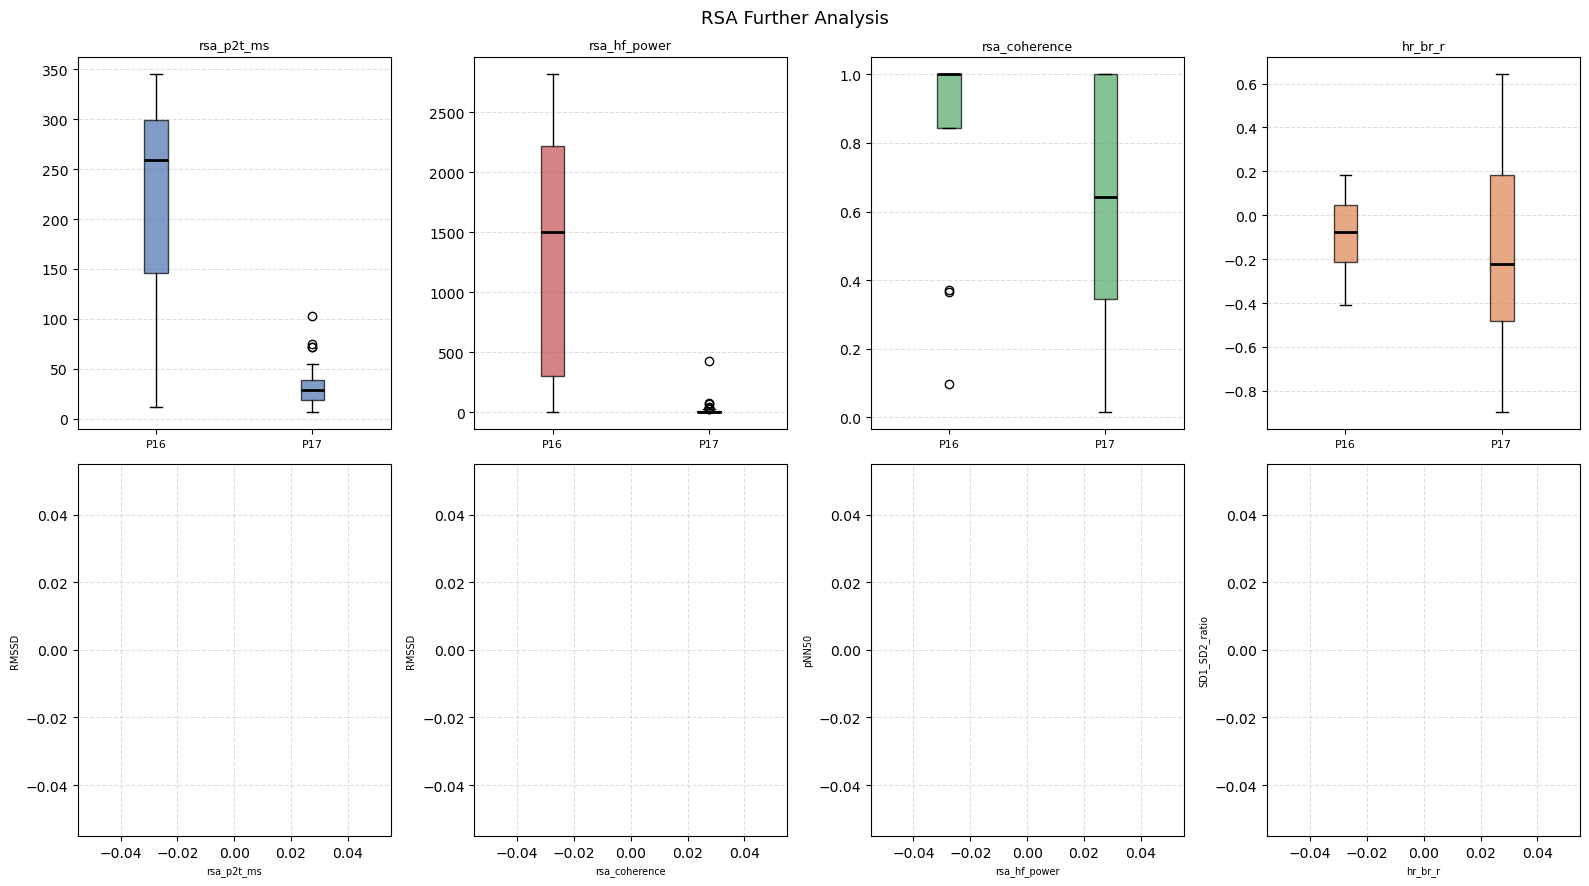

[SAVED] rsa_further_analysis.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


def load_data(base_folder):
    rsa_df = pd.read_csv(os.path.join(base_folder, 'rsa_results.csv'))
    hrv_df = pd.read_csv(os.path.join(base_folder, 'hrv_metrics_all_participants.csv'))
    hrv_df['piece'] = hrv_df.groupby('participant_id')['range_folder'].rank(
                      method='first').astype(int)
    merged = pd.merge(rsa_df, hrv_df[['participant_id','piece','RMSSD','pNN50','SD1_SD2_ratio']],
                      on=['participant_id','piece'], how='inner')
    print(f"[INFO] RSA rows: {len(rsa_df)}  Merged rows: {len(merged)}")
    return rsa_df, hrv_df, merged


def step1_rsa_across_pieces(rsa_df):
    """Test if RSA changes across pieces - does music affect vagal tone?"""
    print(f"\n{'='*55}\n  STEP 1 - RSA ACROSS PIECES\n{'='*55}")
    cols   = ['rsa_p2t_ms','rsa_hf_power','rsa_coherence','hr_br_r']
    pieces = sorted(rsa_df['piece'].unique())

    for col in cols:
        groups = [rsa_df[rsa_df['piece']==p][col].dropna().tolist() for p in pieces]
        groups = [g for g in groups if len(g) >= 3]
        if len(groups) < 2: continue
        stat, p = stats.kruskal(*groups)
        means   = [rsa_df[rsa_df['piece']==p][col].mean() for p in pieces]
        print(f"\n  {col}:")
        for piece, mean in zip(pieces, means):
            print(f"    Piece {piece}: {mean:.3f}")
        print(f"    Kruskal-Wallis H={stat:.3f}  p={p:.4f}  "
              f"{'sig *' if p<0.05 else 'not sig'}")


def step2_rsa_vs_hrv(merged):
    """Correlate RSA metrics with HRV metrics."""
    print(f"\n{'='*55}\n  STEP 2 - RSA vs HRV METRICS\n{'='*55}")
    rsa_cols = ['rsa_p2t_ms','rsa_hf_power','rsa_coherence','hr_br_r','peak_lag_s']
    hrv_cols = ['RMSSD','pNN50','SD1_SD2_ratio']

    print(f"  {'RSA':<20} {'HRV':<15} {'r':>8} {'p':>8} {'Sig':>6}")
    print(f"  {'-'*55}")
    for rc in rsa_cols:
        for hc in hrv_cols:
            v = merged[[rc, hc]].dropna()
            if len(v) < 3: continue
            r, p = stats.pearsonr(v[rc], v[hc])
            print(f"  {rc:<20} {hc:<15} {r:>8.4f} {p:>8.4f} "
                  f"{'YES *' if p<0.05 else 'no':>6}")


def step3_rsa_vagal_tone(rsa_df):
    """
    Classify each recording into vagal tone categories
    using RSA P2T and coherence together.
    High P2T + High coherence = strong vagal modulation
    """
    print(f"\n{'='*55}\n  STEP 3 - VAGAL TONE CLASSIFICATION\n{'='*55}")

    df = rsa_df.copy()
    df['vagal_category'] = 'Unknown'
    df.loc[(df['rsa_p2t_ms']  > 50) & (df['rsa_coherence'] > 0.5), 'vagal_category'] = 'High'
    df.loc[(df['rsa_p2t_ms'].between(20,50)) | (df['rsa_coherence'].between(0.3,0.5)),
            'vagal_category'] = 'Moderate'
    df.loc[(df['rsa_p2t_ms']  < 20) & (df['rsa_coherence'] < 0.3), 'vagal_category'] = 'Low'

    print(df.groupby(['piece','vagal_category']).size().unstack(fill_value=0).to_string())

    pct = df.groupby('piece')['vagal_category'].value_counts(normalize=True).mul(100).round(1)
    print(f"\n  Percentage per piece:")
    print(pct.to_string())
    return df


def step4_lag_analysis(rsa_df):
    """
    Analyze peak lag - how quickly does HR respond to breathing changes?
    Negative lag = HR leads breathing (anticipatory)
    Positive lag = HR follows breathing (reactive)
    """
    print(f"\n{'='*55}\n  STEP 4 - HR-BR LAG ANALYSIS\n{'='*55}")

    print(f"  Overall mean lag : {rsa_df['peak_lag_s'].mean():.2f}s")
    print(f"  Std lag          : {rsa_df['peak_lag_s'].std():.2f}s")
    print(f"  Anticipatory (<0): {(rsa_df['peak_lag_s']<0).sum()} recordings")
    print(f"  Reactive (>0)    : {(rsa_df['peak_lag_s']>0).sum()} recordings")

    print(f"\n  Lag per piece:")
    for piece, grp in rsa_df.groupby('piece'):
        lag = grp['peak_lag_s']
        print(f"    Piece {piece}: mean={lag.mean():.2f}s  "
              f"anticipatory={( lag<0).sum()}  reactive={(lag>0).sum()}")


def step5_responders(rsa_df):
    """
    Identify participants with consistently high vs low RSA
    across all pieces - music responders vs non-responders.
    """
    print(f"\n{'='*55}\n  STEP 5 - RSA RESPONDERS\n{'='*55}")

    pid_means = rsa_df.groupby('participant_id')['rsa_p2t_ms'].mean()
    threshold = pid_means.median()

    high = pid_means[pid_means >= threshold].index.tolist()
    low  = pid_means[pid_means <  threshold].index.tolist()

    print(f"  Threshold (median P2T): {threshold:.2f}ms")
    print(f"  High RSA responders   : {len(high)}")
    print(f"  Low RSA responders    : {len(low)}")

    # Test if responder groups differ in coherence
    h_coh = rsa_df[rsa_df['participant_id'].isin(high)]['rsa_coherence'].dropna()
    l_coh = rsa_df[rsa_df['participant_id'].isin(low)]['rsa_coherence'].dropna()
    stat, p = stats.mannwhitneyu(h_coh, l_coh)
    print(f"\n  Coherence high vs low RSA group:")
    print(f"  High={h_coh.mean():.3f}  Low={l_coh.mean():.3f}  "
          f"p={p:.4f}  {'sig *' if p<0.05 else 'not sig'}")
    return high, low


def step6_piece1_vs_piece3(merged):
    """
    Paired comparison of RSA and HRV between first and last piece.
    Tests if cumulative music exposure affects vagal tone.
    """
    print(f"\n{'='*55}\n  STEP 6 - PIECE 1 vs PIECE 3 PAIRED TEST\n{'='*55}")

    cols = ['rsa_p2t_ms','rsa_hf_power','rsa_coherence','RMSSD','pNN50','SD1_SD2_ratio']
    cols = [c for c in cols if c in merged.columns]

    p1 = merged[merged['piece']==1].set_index('participant_id')
    p3 = merged[merged['piece']==3].set_index('participant_id')
    common = p1.index.intersection(p3.index)

    print(f"  Participants with both pieces: {len(common)}")
    print(f"\n  {'Metric':<20} {'Piece1':>8} {'Piece3':>8} {'Change':>8} {'p':>8} {'Sig':>6}")
    print(f"  {'-'*58}")

    for col in cols:
        v1 = p1.loc[common, col].dropna()
        v3 = p3.loc[common, col].dropna()
        idx = v1.index.intersection(v3.index)
        if len(idx) < 3: continue
        stat, p = stats.wilcoxon(v1[idx], v3[idx])
        change  = v3[idx].mean() - v1[idx].mean()
        arrow   = '↑' if change > 0 else '↓'
        print(f"  {col:<20} {v1[idx].mean():>8.3f} {v3[idx].mean():>8.3f} "
              f"{change:>+7.3f}{arrow} {p:>8.4f} {'YES *' if p<0.05 else 'no':>6}")


def plot_all(rsa_df, merged, base_folder):
    cols   = ['rsa_p2t_ms','rsa_hf_power','rsa_coherence','hr_br_r']
    pieces = sorted(rsa_df['piece'].unique())
    colors = ['#4C72B0','#C44E52','#55A868','#DD8452']

    fig, axes = plt.subplots(2, len(cols), figsize=(4*len(cols), 9))
    fig.suptitle('RSA Further Analysis', fontsize=13)

    # Row 1 - Boxplots per piece
    for ax, col, color in zip(axes[0], cols, colors):
        ax.boxplot([rsa_df[rsa_df['piece']==p][col].dropna() for p in pieces],
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
        ax.set_xticklabels([f'P{p}' for p in pieces], fontsize=8)
        ax.set_title(col, fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Row 2 - RSA vs HRV scatter (for available HRV metrics)
    hrv_pairs = [('rsa_p2t_ms','RMSSD'),('rsa_coherence','RMSSD'),
                 ('rsa_hf_power','pNN50'),('hr_br_r','SD1_SD2_ratio')]
    for ax, (rc, hc) in zip(axes[1], hrv_pairs):
        if rc not in merged.columns or hc not in merged.columns:
            continue
        v = merged[[rc, hc]].dropna()
        ax.scatter(v[rc], v[hc], alpha=0.5, s=30, color='#4C72B0')
        if len(v) >= 3:
            m, b = np.polyfit(v[rc], v[hc], 1)
            x    = np.linspace(v[rc].min(), v[rc].max(), 50)
            ax.plot(x, m*x+b, 'r--', linewidth=1.5)
            r, p = stats.pearsonr(v[rc], v[hc])
            ax.set_title(f'{rc} vs {hc}\nr={r:.3f}  p={p:.4f}', fontsize=8)
        ax.set_xlabel(rc, fontsize=7)
        ax.set_ylabel(hc, fontsize=7)
        ax.grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'rsa_further_analysis.png'), dpi=150)
    plt.show()
    print(f"[SAVED] rsa_further_analysis.png")


if __name__ == '__main__':
    base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'

    rsa_df, hrv_df, merged = load_data(base_folder)

    step1_rsa_across_pieces(rsa_df)
    step2_rsa_vs_hrv(merged)
    vagal_df              = step3_rsa_vagal_tone(rsa_df)
    step4_lag_analysis(rsa_df)
    high_r, low_r         = step5_responders(rsa_df)
    step6_piece1_vs_piece3(merged)
    plot_all(rsa_df, merged, base_folder)

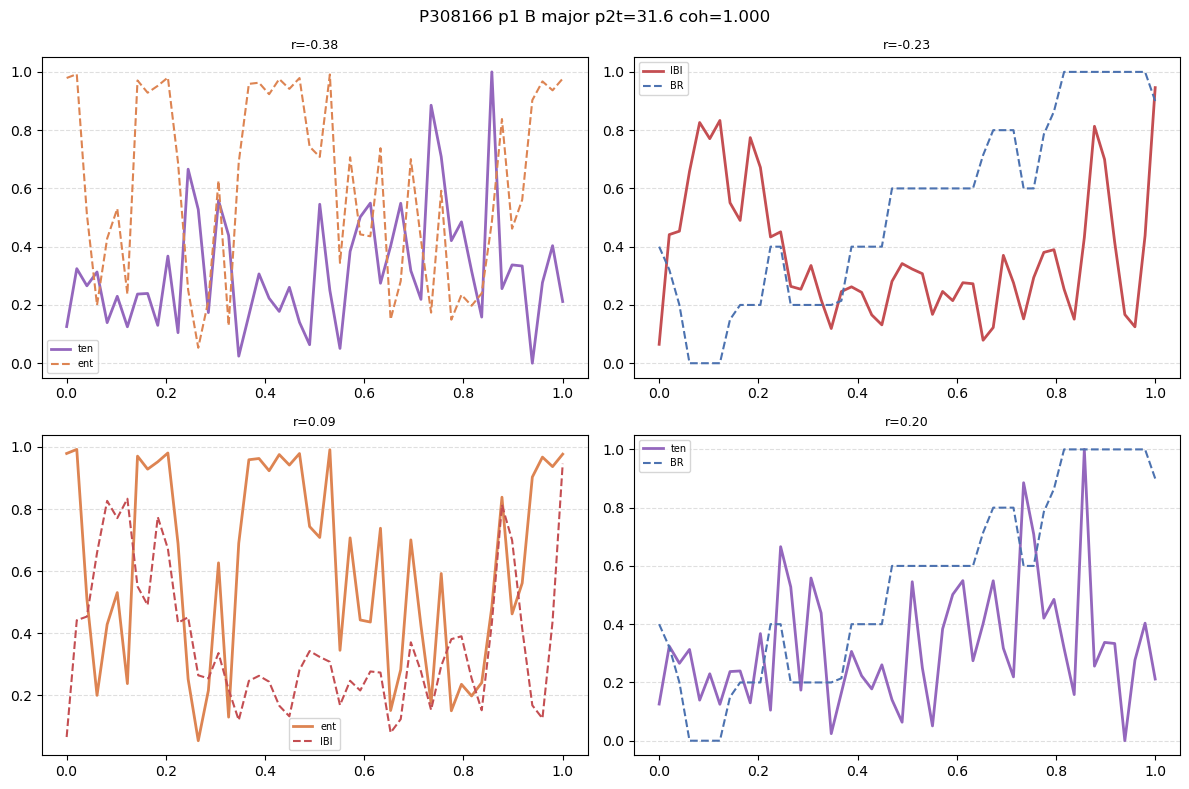

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\rsa_P308166_p1.png
[DONE] P308166 p1 B major ent=1.84 p2t=31.6 coh=1.000


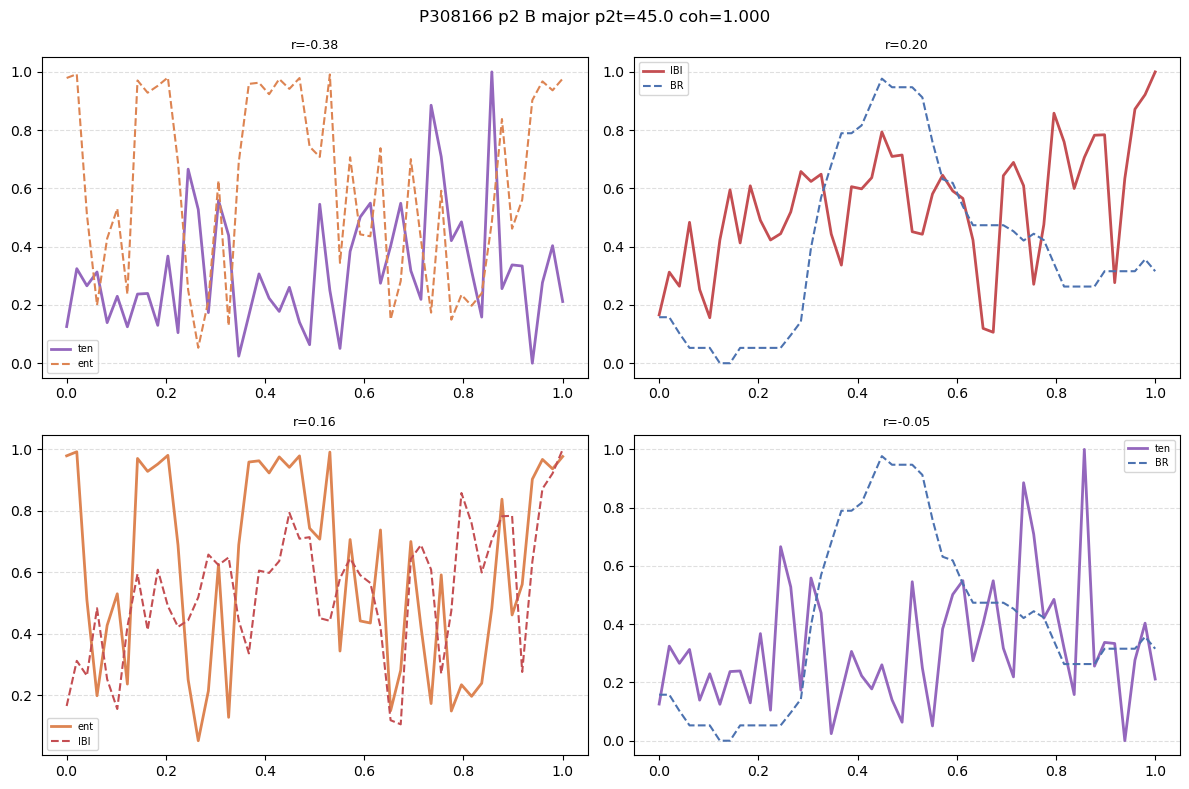

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\rsa_P308166_p2.png
[DONE] P308166 p2 B major ent=1.84 p2t=45.0 coh=1.000


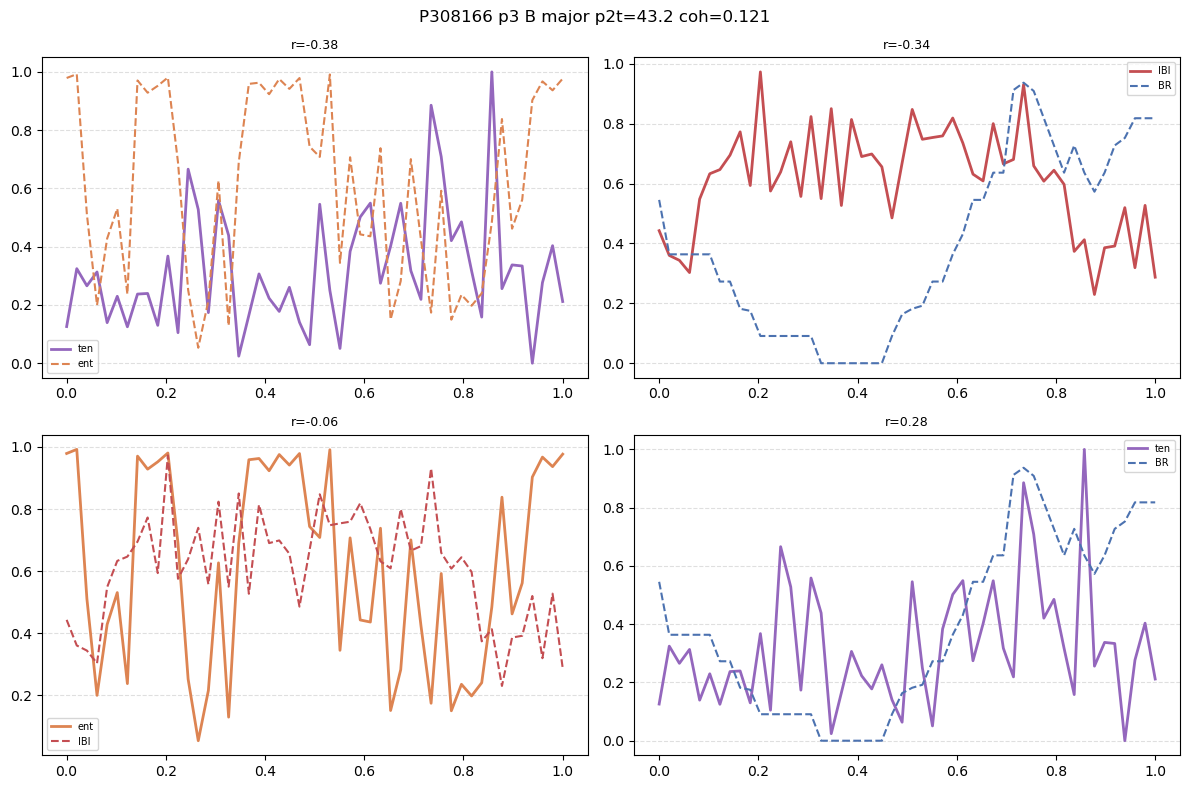

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\rsa_P308166_p3.png
[DONE] P308166 p3 B major ent=1.84 p2t=43.2 coh=0.121
[DONE] P308168 p1 G minor ent=1.62 p2t=304.2 coh=0.365
[DONE] P308168 p2 G minor ent=1.70 p2t=297.9 coh=1.000
[DONE] P308168 p3 E minor ent=1.98 p2t=271.4 coh=1.000
[DONE] P308169 p1 G minor ent=1.52 p2t=11.4 coh=1.000
[DONE] P308169 p2 D minor ent=1.73 p2t=176.5 coh=1.000
[DONE] P308169 p3 F minor ent=1.95 p2t=53.3 coh=0.525
[DONE] P308232 p1 G minor ent=1.51 p2t=15.5 coh=1.000
[DONE] P308232 p2 G minor ent=1.61 p2t=14.5 coh=1.000
[DONE] P308232 p3 A# minor ent=1.84 p2t=9.6 coh=0.549
[DONE] P308233 p1 G minor ent=1.83 p2t=37.8 coh=0.595
[DONE] P308233 p2 G minor ent=1.68 p2t=41.6 coh=1.000
[DONE] P308233 p3 A major ent=1.77 p2t=55.4 coh=0.099
[DONE] P308234 p1 G minor ent=1.52 p2t=29.8 coh=0.423
[DONE] P308234 p2 G minor ent=1.73 p2t=39.8 coh=1.000
[DONE] P308234 p3 G# major ent=1.86 p2t=40.9 coh=0.170
[DONE] P308235 p1 G minor ent=1.55 p2t=19.0 coh=1.000


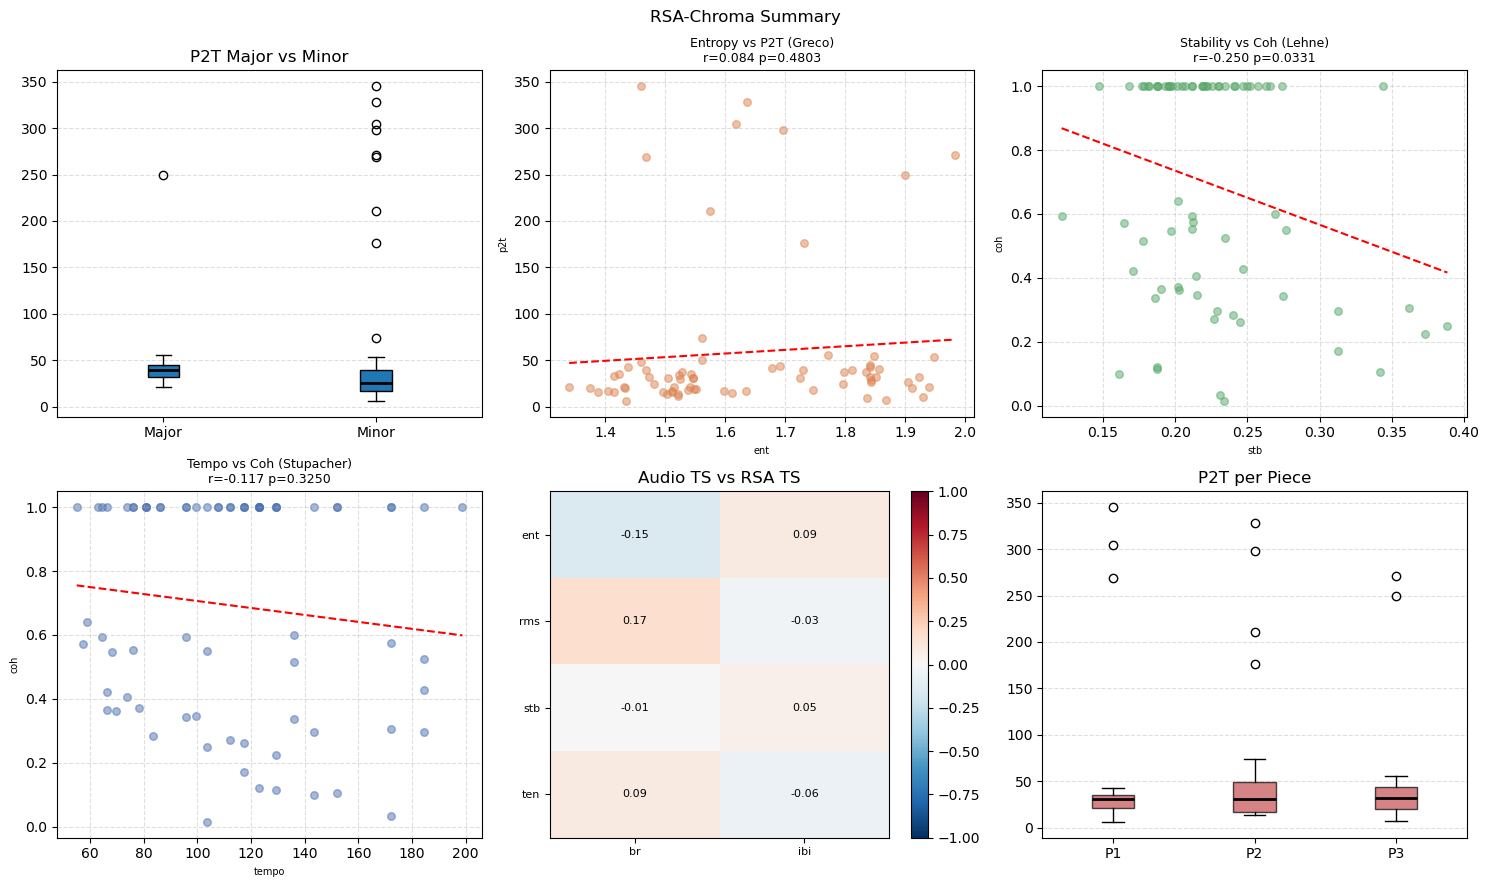

[SAVED] rsa_chroma_summary.png


In [ ]:
import os,sys,re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats,signal
from scipy.interpolate import interp1d
from pydub import AudioSegment
import librosa,warnings
warnings.filterwarnings('ignore')

NN=['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
MP=np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
MN=np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])

def nr(a,n=50):
    mn,mx=a.min(),a.max(); a=(a-mn)/(mx-mn) if mx!=mn else np.zeros_like(a)
    return interp1d(np.linspace(0,1,len(a)),a,bounds_error=False,fill_value='extrapolate')(np.linspace(0,1,n))

def mode(cm):
    c=lambda p:[np.corrcoef(np.roll(p,i),cm)[0,1] for i in range(12)]
    mj,mn=c(MP),c(MN)
    return (NN[int(np.argmax(mj))],'major',max(mj)) if max(mj)>max(mn) else (NN[int(np.argmax(mn))],'minor',max(mn))

def load_mp3(p,sr=22050):
    a=AudioSegment.from_file(p,format='mp3').set_channels(1).set_frame_rate(sr)
    return np.array(a.get_array_of_samples()).astype(np.float32)/np.iinfo(np.int16).max,sr

def audio_features(p,n=50):
    y,sr=load_mp3(p); t,_=librosa.beat.beat_track(y=y,sr=sr)
    ch=librosa.feature.chroma_stft(y=y,sr=sr)
    rms=librosa.feature.rms(y=y)[0]; sp=librosa.feature.spectral_centroid(y=y,sr=sr)[0]
    on=librosa.onset.onset_strength(y=y,sr=sr)
    cn=ch/(ch.sum(0,keepdims=True)+1e-9)
    ent=-np.sum(cn*np.log(cn+1e-9),0)
    stb=np.nan_to_num([np.corrcoef(ch[:,i],ch.mean(1))[0,1] for i in range(ch.shape[1])])
    np_=min(len(rms),len(sp),len(on),len(ent),len(stb))
    ten=nr(rms[:np_])*0.4+nr(sp[:np_])*0.3+nr(on[:np_])*0.3
    k,m,c=mode(ch.mean(1))
    return ({'tempo':round(float(t),1),'key':k,'mode':m,'conf':round(c,4),
             'ent':round(float(ent[:np_].mean()),4),'stb':round(float(stb[:np_].mean()),4),
             'ten':round(float(ten.mean()),4)},
            {f:nr(a[:np_],n) for f,a in [('ent',ent),('stb',stb),('ten',ten),('rms',rms)]})

def load_wav(folder,fname,lo,hi):
    sys.path.insert(0,folder)
    import load_hx_data; load_hx_data.set_device_model('hx')
    p=os.path.join(folder,fname)
    if not os.path.exists(p): return None,None
    df=pd.DataFrame(load_hx_data.load_wave(p),columns=['t','v'])
    t,v=df['t'].to_numpy(),df['v'].to_numpy()
    if v.mean()>1000: v=v/1000
    m=(v>=lo)&(v<=hi)
    return (t[m],v[m]) if m.sum()>=3 else (None,None)

def rsa(rr_t,rr_v,br_t,br_v,sr=4):
    t0,t1=max(rr_t[0],br_t[0]),min(rr_t[-1],br_t[-1])
    if t1-t0<10: return None
    tc=np.arange(t0,t1,1/sr)
    ib=interp1d(rr_t,rr_v*1000,bounds_error=False,fill_value='extrapolate')(tc)
    br=interp1d(br_t,br_v,bounds_error=False,fill_value='extrapolate')(tc)
    pk,_=signal.find_peaks(np.convolve(br,np.ones(10)/10,'same'),distance=sr*2)
    p2t=[np.ptp(ib[pk[i]:pk[i+1]]) for i in range(len(pk)-1) if len(ib[pk[i]:pk[i+1]])>1]
    f,ps=signal.welch(ib,fs=sr,nperseg=min(256,len(ib))); hf=(f>=.15)&(f<=.4)
    fc,co=signal.coherence(ib,br,fs=sr,nperseg=min(256,len(ib))); hc=(fc>=.15)&(fc<=.4)
    r,_=stats.pearsonr(ib,br)
    return {'p2t':round(float(np.mean(p2t)),2) if p2t else np.nan,
            'hf':round(float(np.trapz(ps[hf],f[hf])),4) if hf.sum() else np.nan,
            'coh':round(float(np.mean(co[hc])),4) if hc.sum() else np.nan,
            'r':round(float(r),4),'ib':ib,'br':br,'tc':tc}

def maps(af,bf):
    am={}
    for f in sorted(os.listdir(af)):
        m=re.search(r'P(\d+)_video(\d+)',f)
        if m: am.setdefault(m.group(1),{})[int(m.group(2))]=os.path.join(af,f)
    hm={}
    for rf in sorted(os.listdir(bf)):
        rp=os.path.join(bf,rf)
        if not os.path.isdir(rp): continue
        for rc in sorted(os.listdir(rp)):
            rcp=os.path.join(rp,rc)
            if not os.path.isdir(rcp): continue
            m=re.search(r'record_(\d+)',rc)
            if not m: continue
            fo=os.path.join(rcp,rc)
            if not os.path.isdir(fo): fo=rcp
            hm.setdefault(m.group(1),[]).append((rf,fo))
    for pid in hm: hm[pid]=sorted(hm[pid],key=lambda x:x[0])
    pm={a:h for a,h in zip(sorted(am,key=int),sorted(hm,key=int))}
    am={pm[a]:p for a,p in am.items() if a in pm}
    return am,hm,sorted(set(am)&set(hm),key=int)

def sc(ax,df,x,y,c,ttl):
    v=df[[x,y]].dropna()
    if len(v)<3: return
    ax.scatter(v[x],v[y],alpha=0.5,s=30,color=c)
    m,b=np.polyfit(v[x],v[y],1); xr=np.linspace(v[x].min(),v[x].max(),50)
    ax.plot(xr,m*xr+b,'r--',lw=1.5)
    r,p=stats.pearsonr(v[x],v[y])
    ax.set_title(f'{ttl}\nr={r:.3f} p={p:.4f}',fontsize=9)
    ax.set_xlabel(x,fontsize=7); ax.set_ylabel(y,fontsize=7)
    ax.grid(linestyle='--',alpha=0.4)

def run(audio_folder,base_folder,n=50,max_plots=3):
    am,hm,common=maps(audio_folder,base_folder)
    rows,tsc,np_=[], [],0
    for pid in common:
        for piece,(rf,folder) in enumerate(hm[pid][:3],1):
            ap=am.get(pid,{}).get(piece)
            if ap is None: continue
            try:
                as_,at=audio_features(ap,n)
                rc=os.path.join(folder,'RR_interval.csv')
                if not os.path.exists(rc): continue
                rd=pd.read_csv(rc); rt,rv=rd.iloc[:,0].to_numpy(),rd.iloc[:,1].to_numpy()
                if rv.mean()>10: rv=rv/1000.0
                bt,bv=load_wav(folder,'breathing_rate.wav',2,60)
                if bv is None: continue
                rs=rsa(rt,rv,bt,bv)
                if rs is None: continue
                iz,bz=nr(rs['ib'],n),nr(rs['br'],n)
                for af,av in at.items():
                    for pf,pv in [('ibi',iz),('br',bz)]:
                        r,p=stats.pearsonr(av,pv)
                        tsc.append({'pid':pid,'piece':piece,'af':af,'pf':pf,
                                    'r':round(r,4),'p':round(p,4),'sig':p<0.05})
                rows.append({'pid':pid,'piece':piece,**as_,
                             'p2t':rs['p2t'],'hf':rs['hf'],'coh':rs['coh'],'r':rs['r']})
                if np_<max_plots:
                    plot_ov(at,iz,bz,rs,as_,pid,piece,base_folder); np_+=1
                print(f"[DONE] P{pid} p{piece} {as_['key']} {as_['mode']} "
                      f"ent={as_['ent']:.2f} p2t={rs['p2t']:.1f} coh={rs['coh']:.3f}")
            except Exception as e: print(f"[ERROR] P{pid} p{piece} - {e}")

    df=pd.DataFrame(rows); td=pd.DataFrame(tsc)
    if df.empty: print("[WARN] No data"); return df,td
    df.to_csv(os.path.join(base_folder,'rsa_chroma.csv'),index=False)
    td.to_csv(os.path.join(base_folder,'rsa_chroma_ts.csv'),index=False)
    stats_print(df,td); plot_sum(df,td,base_folder)
    return df,td

def stats_print(df,td):
    for ttl,c1,c2,ref in [("MAJOR vs MINOR",'mode','p2t','Bowling/Koelsch'),
                           ("ENTROPY vs P2T",'ent','p2t','Greco/Jiang'),
                           ("STABILITY vs COH",'stb','coh','Lehne 2023'),
                           ("TEMPO vs COH",'tempo','coh','Stupacher 2022')]:
        print(f"\n== {ttl} ({ref})")
        if c1=='mode':
            mj,mn=df[df['mode']=='major'][c2].dropna(),df[df['mode']=='minor'][c2].dropna()
            [print(f"  {m}: {v.mean():.3f} n={len(v)}") for m,v in [('major',mj),('minor',mn)]]
            if len(mj)>=2 and len(mn)>=2:
                _,p=stats.mannwhitneyu(mj,mn); print(f"  p={p:.4f} {'*' if p<0.05 else ''}")
        else:
            v=df[[c1,c2]].dropna()
            if len(v)>=3:
                r,p=stats.pearsonr(v[c1],v[c2]); print(f"  r={r:.4f} p={p:.4f} {'*' if p<0.05 else ''}")
    if not td.empty:
        print("\n== AUDIO TS vs RSA TS")
        g=td.groupby(['af','pf']).agg(r=('r','mean'),s=('sig','mean'),n=('r','count')).reset_index()
        [print(f"  {row.af:<10} {row.pf:<5} r={row.r:.4f} %sig={row.s*100:.0f}%")
         for _,row in g.sort_values('r',key=abs,ascending=False).iterrows()]

def plot_ov(at,iz,bz,rs,as_,pid,piece,bf):
    t=np.linspace(0,1,len(iz))
    fig,ax=plt.subplots(2,2,figsize=(12,8))
    fig.suptitle(f'P{pid} p{piece} {as_["key"]} {as_["mode"]} p2t={rs["p2t"]:.1f} coh={rs["coh"]:.3f}')
    for a,(y1,l1,c1),(y2,l2,c2) in [(ax[0,0],(at['ten'],'ten','#9467BD'),(at['ent'],'ent','#DD8452')),
                                      (ax[0,1],(iz,'IBI','#C44E52'),(bz,'BR','#4C72B0')),
                                      (ax[1,0],(at['ent'],'ent','#DD8452'),(iz,'IBI','#C44E52')),
                                      (ax[1,1],(at['ten'],'ten','#9467BD'),(bz,'BR','#4C72B0'))]:
        a.plot(t,y1,color=c1,lw=2,label=l1); a.plot(t,y2,color=c2,lw=1.5,ls='--',label=l2)
        r,_=stats.pearsonr(y1,y2); a.set_title(f'r={r:.2f}',fontsize=9)
        a.legend(fontsize=7); a.grid(axis='y',ls='--',alpha=0.4)
    plt.tight_layout()
    out=os.path.join(bf,f'rsa_P{pid}_p{piece}.png')
    plt.savefig(out,dpi=150,bbox_inches='tight'); plt.show(); print(f"[SAVED] {out}")

def plot_sum(df,td,bf):
    fig,ax=plt.subplots(2,3,figsize=(15,9)); fig.suptitle('RSA-Chroma Summary')
    mj,mn=df[df['mode']=='major']['p2t'].dropna(),df[df['mode']=='minor']['p2t'].dropna()
    ax[0,0].boxplot([mj,mn],patch_artist=True,medianprops=dict(color='black',lw=2))
    ax[0,0].set_xticklabels(['Major','Minor']); ax[0,0].set_title('P2T Major vs Minor')
    ax[0,0].grid(axis='y',ls='--',alpha=0.4)
    sc(ax[0,1],df,'ent','p2t','#DD8452','Entropy vs P2T (Greco)')
    sc(ax[0,2],df,'stb','coh','#55A868','Stability vs Coh (Lehne)')
    sc(ax[1,0],df,'tempo','coh','#4C72B0','Tempo vs Coh (Stupacher)')
    if not td.empty:
        g=td.groupby(['af','pf'])['r'].mean().unstack()
        im=ax[1,1].imshow(g.values,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto')
        ax[1,1].set_xticks(range(len(g.columns))); ax[1,1].set_yticks(range(len(g.index)))
        ax[1,1].set_xticklabels(g.columns,fontsize=8); ax[1,1].set_yticklabels(g.index,fontsize=8)
        [[ax[1,1].text(j,i,f'{g.values[i,j]:.2f}',ha='center',va='center',fontsize=8,
          color='white' if abs(g.values[i,j])>.5 else 'black')
          for j in range(len(g.columns)) if not np.isnan(g.values[i,j])]
         for i in range(len(g.index))]
        plt.colorbar(im,ax=ax[1,1]); ax[1,1].set_title('Audio TS vs RSA TS')
    pieces=sorted(df.piece.unique())
    ax[1,2].boxplot([df[df.piece==p]['p2t'].dropna() for p in pieces],patch_artist=True,
                     boxprops=dict(facecolor='#C44E52',alpha=0.7),medianprops=dict(color='black',lw=2))
    ax[1,2].set_xticklabels([f'P{p}' for p in pieces]); ax[1,2].set_title('P2T per Piece')
    ax[1,2].grid(axis='y',ls='--',alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(bf,'rsa_chroma_summary.png'),dpi=150)
    plt.show(); print("[SAVED] rsa_chroma_summary.png")

if __name__=='__main__':
    df,td=run(r'C:\Users\manognas\Downloads\2inspire_audio\audio',
              r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin')

Running ISC...
[ISC] Piece 1 n=25 IBI=0.033 BR=0.048
[ISC] Piece 2 n=25 IBI=0.006 BR=0.163
[ISC] Piece 3 n=24 IBI=0.007 BR=-0.005


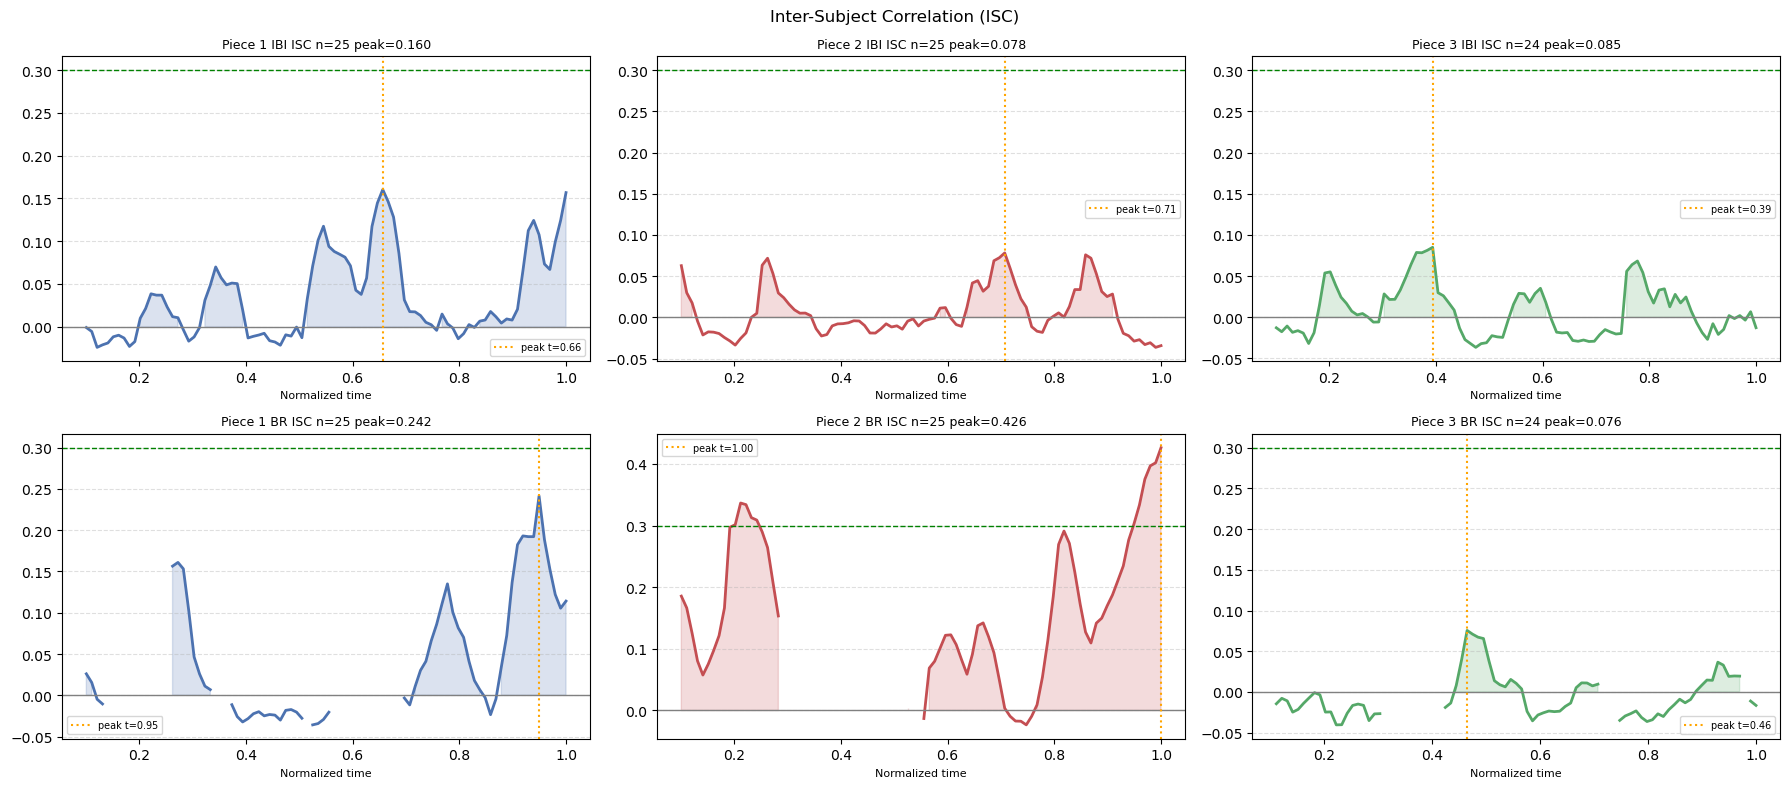

[SAVED] isc.png

Running Clustering...
[INFO] Clustering 22 participants

  CLUSTER PROFILES

  Cluster 0 (n=13)  STRONG RESPONDERS
    rmssd_chg: 36.475±102.388
    p2t: 36.704±16.749
    coh: 0.630±0.125
    sd1sd2: 0.282±0.091
    pnn50: 51.212±12.947

  Cluster 1 (n=1)  STRONG RESPONDERS
    rmssd_chg: -1037.269±nan
    p2t: 239.383±nan
    coh: 0.462±nan
    sd1sd2: 0.394±nan
    pnn50: 46.497±nan

  Cluster 2 (n=8)  WEAK RESPONDERS
    rmssd_chg: -0.631±14.967
    p2t: 22.586±11.249
    coh: 0.737±0.227
    sd1sd2: 0.172±0.044
    pnn50: 18.343±13.867

  Kruskal-Wallis:


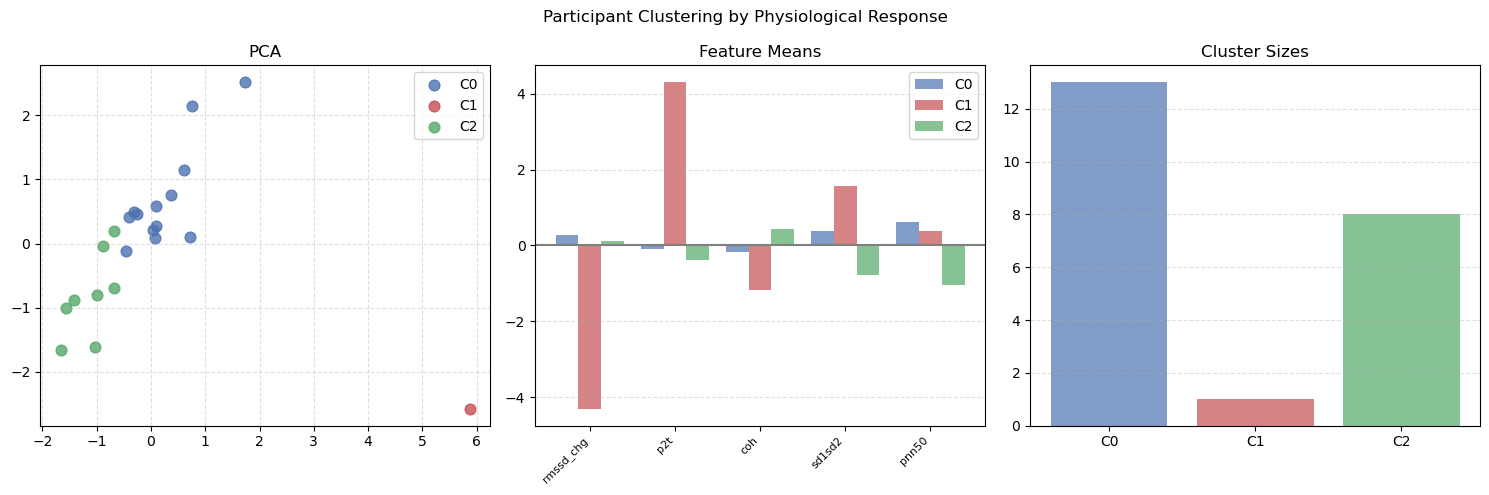

[SAVED] clustering.png

Note: Rolling correlation requires audio_ts_dict from rsa_chroma_analysis.py


In [ ]:
import os,sys,re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats,signal
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

def load_wav(folder,fname,lo,hi):
    sys.path.insert(0,folder)
    import load_hx_data; load_hx_data.set_device_model('hx')
    p=os.path.join(folder,fname)
    if not os.path.exists(p): return None,None
    df=pd.DataFrame(load_hx_data.load_wave(p),columns=['t','v'])
    t,v=df['t'].to_numpy(),df['v'].to_numpy()
    if v.mean()>1000: v=v/1000
    m=(v>=lo)&(v<=hi)
    return (t[m],v[m]) if m.sum()>=3 else (None,None)

def load_rr(folder):
    p=os.path.join(folder,'RR_interval.csv')
    if not os.path.exists(p): return None,None
    df=pd.read_csv(p); t,rr=df.iloc[:,0].to_numpy(),df.iloc[:,1].to_numpy()
    if rr.mean()>10: rr=rr/1000
    return t,rr

def nr(a,n):
    mn,mx=a.min(),a.max(); a=(a-mn)/(mx-mn) if mx!=mn else np.zeros_like(a)
    return interp1d(np.linspace(0,1,len(a)),a,bounds_error=False,fill_value='extrapolate')(np.linspace(0,1,n))

def to_ibi(rr_t,rr_v,sr=4):
    t0,t1=rr_t[0],rr_t[-1]
    if t1-t0<10: return None,None
    tc=np.arange(t0,t1,1/sr)
    return tc,interp1d(rr_t,rr_v*1000,bounds_error=False,fill_value='extrapolate')(tc)

def build_maps(bf):
    hm={}
    for rf in sorted(os.listdir(bf)):
        rp=os.path.join(bf,rf)
        if not os.path.isdir(rp): continue
        for rc in sorted(os.listdir(rp)):
            rcp=os.path.join(rp,rc)
            if not os.path.isdir(rcp): continue
            m=re.search(r'record_(\d+)',rc)
            if not m: continue
            fo=os.path.join(rcp,rc)
            if not os.path.isdir(fo): fo=rcp
            hm.setdefault(m.group(1),[]).append((rf,fo))
    for pid in hm: hm[pid]=sorted(hm[pid],key=lambda x:x[0])
    return hm

def roll_r(a,b,w):
    n=len(a); r=np.full(n,np.nan)
    for i in range(w,n):
        if np.std(a[i-w:i])>0 and np.std(b[i-w:i])>0:
            r[i],_=stats.pearsonr(a[i-w:i],b[i-w:i])
    return r

# ── Analysis 1: Rolling Correlation ───────────────────────────────────────────

def run_rolling(bf,audio_ts_dict,n=100,w=20):
    hm=build_maps(bf); rows=[]
    for pid,pieces in hm.items():
        if pid not in audio_ts_dict: continue
        for piece,(rf,folder) in enumerate(pieces[:3],1):
            if piece not in audio_ts_dict[pid]: continue
            rr_t,rr_v=load_rr(folder)
            br_t,br_v=load_wav(folder,'breathing_rate.wav',2,60)
            if rr_v is None or br_v is None: continue
            tc,ibi=to_ibi(rr_t,rr_v)
            if ibi is None: continue
            iz,bz=nr(ibi,n),nr(br_v,n)
            for feat,av in audio_ts_dict[pid][piece].items():
                ar=nr(av,n)
                for sn,sv in [('ibi',iz),('br',bz)]:
                    rows.append({'pid':pid,'piece':piece,'feat':feat,'sig':sn,'rr':roll_r(ar,sv,w)})
    plot_rolling(rows,bf); return rows

def plot_rolling(rows,bf,feats=['tension','entropy']):
    t=np.linspace(0,1,100)
    fig,axes=plt.subplots(len(feats),2,figsize=(13,4*len(feats)))
    fig.suptitle('Rolling Correlation - When Does Coupling Peak?',fontsize=12)
    for ri,feat in enumerate(feats):
        for ci,sig in enumerate(['ibi','br']):
            ax=axes[ri,ci]
            sub=[r['rr'] for r in rows if r['feat']==feat and r['sig']==sig]
            if not sub: continue
            mat=np.vstack(sub); mn=np.nanmean(mat,0); se=np.nanstd(mat,0)/np.sqrt(mat.shape[0])
            ax.plot(t,mn,color='#4C72B0',lw=2,label='Mean r')
            ax.fill_between(t,mn-se,mn+se,alpha=0.2,color='#4C72B0')
            ax.axhline(0,color='gray',lw=1)
            [ax.axhline(v,color=c,ls='--',lw=1,label=f'r={v}')
             for v,c in [(0.3,'green'),(-0.3,'red')]]
            pt=t[np.nanargmax(np.abs(mn))]; pr=mn[np.nanargmax(np.abs(mn))]
            ax.axvline(pt,color='orange',ls=':',lw=1.5,label=f'peak t={pt:.2f}')
            ax.set_title(f'{feat} vs {sig}  peak r={pr:.3f}',fontsize=9)
            ax.set_xlabel('Normalized time',fontsize=8); ax.legend(fontsize=7)
            ax.grid(axis='y',ls='--',alpha=0.4)
    plt.tight_layout(); plt.savefig(os.path.join(bf,'rolling_corr.png'),dpi=150)
    plt.show(); print('[SAVED] rolling_corr.png')

# ── Analysis 2: ISC ────────────────────────────────────────────────────────────

def run_isc(bf,n=100,w=10):
    hm=build_maps(bf); results={}
    for pn in [1,2,3]:
        ibi_m,br_m=[],[]
        for pid,pieces in hm.items():
            if pn>len(pieces): continue
            _,folder=pieces[pn-1]
            rr_t,rr_v=load_rr(folder); br_t,br_v=load_wav(folder,'breathing_rate.wav',2,60)
            if rr_v is None or br_v is None: continue
            tc,ibi=to_ibi(rr_t,rr_v)
            if ibi is None: continue
            ibi_m.append(nr(ibi,n)); br_m.append(nr(br_v,n))
        if len(ibi_m)<3: continue

        def isc_roll(mat):
            out=np.full(n,np.nan)
            for i in range(w,n):
                rs=[stats.pearsonr(mat[a,i-w:i],mat[b,i-w:i])[0]
                    for a in range(len(mat)) for b in range(a+1,len(mat))
                    if np.std(mat[a,i-w:i])>0 and np.std(mat[b,i-w:i])>0]
                if rs: out[i]=np.mean(rs)
            return out

        im=np.vstack(ibi_m); bm=np.vstack(br_m)
        results[pn]={'ibi':isc_roll(im),'br':isc_roll(bm),'n':len(ibi_m)}
        print(f"[ISC] Piece {pn} n={len(ibi_m)} IBI={np.nanmean(results[pn]['ibi']):.3f} "
              f"BR={np.nanmean(results[pn]['br']):.3f}")

    plot_isc(results,bf); return results

def plot_isc(results,bf):
    t=np.linspace(0,1,100); cols=['#4C72B0','#C44E52','#55A868']
    fig,axes=plt.subplots(2,len(results),figsize=(6*len(results),8))
    fig.suptitle('Inter-Subject Correlation (ISC)',fontsize=12)
    for ci,(pn,res) in enumerate(results.items()):
        for ri,(key,lbl) in enumerate([('ibi','IBI'),('br','BR')]):
            ax=axes[ri,ci]; isc=res[key]
            ax.plot(t,isc,color=cols[ci],lw=2)
            ax.fill_between(t,isc,0,where=(isc>0),alpha=0.2,color=cols[ci])
            ax.axhline(0,color='gray',lw=1); ax.axhline(0.3,color='green',ls='--',lw=1)
            pt=t[np.nanargmax(isc)] if not np.all(np.isnan(isc)) else 0
            pv=np.nanmax(isc) if not np.all(np.isnan(isc)) else 0
            ax.axvline(pt,color='orange',ls=':',lw=1.5,label=f'peak t={pt:.2f}')
            ax.set_title(f'Piece {pn} {lbl} ISC n={res["n"]} peak={pv:.3f}',fontsize=9)
            ax.set_xlabel('Normalized time',fontsize=8); ax.legend(fontsize=7)
            ax.grid(axis='y',ls='--',alpha=0.4)
    plt.tight_layout(); plt.savefig(os.path.join(bf,'isc.png'),dpi=150)
    plt.show(); print('[SAVED] isc.png')

# ── Analysis 3: Clustering ─────────────────────────────────────────────────────

def run_clustering(bf,k=3):
    h=os.path.join(bf,'hrv_metrics_all_participants.csv')
    r=os.path.join(bf,'rsa_chroma.csv')
    if not os.path.exists(h) or not os.path.exists(r):
        print('[MISSING] Run hrv_boxplot.py and rsa_chroma_analysis.py first'); return None
    hd=pd.read_csv(h); rd=pd.read_csv(r)
    hd['participant_id']=hd['participant_id'].astype(str)
    rd['pid']=rd['pid'].astype(str)
    hd['piece']=hd.groupby('participant_id')['range_folder'].rank(method='first').astype(int)

    p1=hd[hd['piece']==1].set_index('participant_id')['RMSSD']
    p3=hd[hd['piece']==3].set_index('participant_id')['RMSSD']
    df=pd.concat([(p3-p1).rename('rmssd_chg'),
                   rd.groupby('pid')['p2t'].mean().rename('p2t'),
                   rd.groupby('pid')['coh'].mean().rename('coh'),
                   hd.groupby('participant_id')['SD1_SD2_ratio'].mean().rename('sd1sd2'),
                   hd.groupby('participant_id')['pNN50'].mean().rename('pnn50')],axis=1).dropna()

    print(f"[INFO] Clustering {len(df)} participants")
    X=StandardScaler().fit_transform(df.values)
    df['cluster']=KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(X)
    Xp=PCA(n_components=2).fit_transform(X)

    print(f"\n{'='*50}\n  CLUSTER PROFILES\n{'='*50}")
    for c in range(k):
        g=df[df['cluster']==c]
        print(f"\n  Cluster {c} (n={len(g)})  "
              f"{'STRONG' if g['p2t'].mean()>df['p2t'].median() else 'WEAK'} RESPONDERS")
        [print(f"    {f}: {g[f].mean():.3f}±{g[f].std():.3f}") for f in df.columns[:-1]]

    print(f"\n  Kruskal-Wallis:")
    for f in df.columns[:-1]:
        gs=[df[df['cluster']==c][f].dropna() for c in range(k)]
        if all(len(g)>=2 for g in gs):
            stat,p=stats.kruskal(*gs)
            print(f"  {f:<12} H={stat:.3f} p={p:.4f} {'*' if p<0.05 else ''}")

    cols=['#4C72B0','#C44E52','#55A868','#DD8452'][:k]
    fig,axes=plt.subplots(1,3,figsize=(15,5))
    fig.suptitle('Participant Clustering by Physiological Response',fontsize=12)
    for c,col in zip(range(k),cols):
        m=df['cluster'].values==c
        axes[0].scatter(Xp[m,0],Xp[m,1],color=col,s=60,alpha=0.8,label=f'C{c}')
    axes[0].set_title('PCA'); axes[0].legend(); axes[0].grid(ls='--',alpha=0.4)

    feats=df.columns[:-1].tolist(); x=np.arange(len(feats)); w=0.8/k
    Xs=StandardScaler().fit_transform(df[feats].values)
    for c,col in zip(range(k),cols):
        cm=Xs[df['cluster'].values==c].mean(0)
        axes[1].bar(x+c*w,cm,w,color=col,alpha=0.7,label=f'C{c}')
    axes[1].set_xticks(x+w); axes[1].set_xticklabels(feats,rotation=45,ha='right',fontsize=8)
    axes[1].set_title('Feature Means'); axes[1].legend(); axes[1].axhline(0,color='gray')
    axes[1].grid(axis='y',ls='--',alpha=0.4)

    axes[2].bar(range(k),[df[df['cluster']==c].shape[0] for c in range(k)],color=cols,alpha=0.7)
    axes[2].set_xticks(range(k)); axes[2].set_xticklabels([f'C{c}' for c in range(k)])
    axes[2].set_title('Cluster Sizes'); axes[2].grid(axis='y',ls='--',alpha=0.4)

    plt.tight_layout(); plt.savefig(os.path.join(bf,'clustering.png'),dpi=150)
    plt.show(); print('[SAVED] clustering.png')
    return df

if __name__=='__main__':
    bf=r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
    print("Running ISC..."); isc=run_isc(bf)
    print("\nRunning Clustering..."); clusters=run_clustering(bf)
    print("\nNote: Rolling correlation requires audio_ts_dict from rsa_chroma_analysis.py")